# 五分

In [26]:
# %pip install matplotlib

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import textwrap
from IPython.display import display
from IPython.display import Markdown
from datetime import datetime
import numpy_financial as npf
import math
import pandas as pd
import numpy as np

# 一般作法

In [30]:
def calculate_irr(signal, threshold):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    balance_in = []  # 每月投入的資金
    balance_total = 0
    month = 1
    this_month_in = 0

    for idx, item in enumerate(signal):
        score = float(item[1])
        price = float(signal[idx][2])
        if score > threshold:
            balance_total += score * 1000  # 買入分數*1000等值的股票
            hold = hold + ((score * 1000) / price)  # 計算持有的股票數

            # 計算每月投入金額
            date_obj = datetime.strptime(item[0], '%Y%m%d')
            if month == date_obj.month:
                this_month_in += score * 1000
            elif month != date_obj.month:
                month = date_obj.month
                this_month_in += score * 1000
                balance_in.append(-this_month_in)
                this_month_in = 0

    balance_in.append(-this_month_in)
    last_price = float(signal[len(signal) - 1][2])
    
    balance_in.append(hold * last_price)
    # print(balance_in)
    irr = npf.irr(balance_in)

    if math.isnan(irr):
        irr = 0

    if balance_total > 0:
        bnh = last_price / float(signal[0][2])
    else:
        bnh = 0

    return round(irr, 5), round(bnh, 5)

In [117]:
def calculate_rtn(signal, threshold):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    retrun = []  # 每月投入的資金
    balance_total = 1000000
    buynhold = []

    for idx, item in enumerate(signal):
        score = float(item[1])
        if idx+1 == len(signal):
            break
        price = float(signal[idx+1][2])
        buynhold.append(price/float(signal[0][2]))

        if score > threshold:
            balance_buy = ((score)/100) * balance_total  # 買入與分數相同百分比的股票
            new_hold = (balance_buy / price)  # 計算持有的股票數
            
            diff = hold - new_hold
            balance_total += diff*price
            hold = new_hold
        
        retrun.append((balance_total + hold*price)/1000000)
        # print(balance_total, hold*price)
    
    balance_total += hold*price

    plt.plot(retrun, label=f'strategy', color='red')
    plt.plot(buynhold, label='buy and hold', color='blue')
    plt.legend()
    plt.show()

    rtn = balance_total/1000000

    if balance_total > 0:
        bnh = float(signal[len(signal)-1][2]) / float(signal[0][2])
    else:
        bnh = 0

    return round(rtn, 5), round(bnh, 5)

In [140]:
def eval(signal):
    # [日期, 評分, 價格]
    hold = 0  # 持有的股數
    retrun = []  # 每月投入的資金
    balance_total = 1000000
    buynhold = []
    t = 0
    f = 0

    for idx, item in enumerate(signal):
        score = float(item[1])
        if idx+1 == len(signal):
            break
        price = float(signal[idx+1][2])
        buynhold.append(price/float(signal[0][2]))

        if score > 0:
            if (price - float(signal[idx][2])) > 0:
                t += 1
            elif (price - float(signal[idx][2])) == 0:
                pass
            else:   
                f+=1

        
    return t, f

__________________________________________________
1 37 27 0.578125
__________________________________________________
2 49 26 0.6533333333333333
__________________________________________________
3 72 43 0.6260869565217392
__________________________________________________
4 46 30 0.6052631578947368
__________________________________________________
5 77 48 0.616
__________________________________________________
6 30 19 0.6122448979591837
__________________________________________________
7 17 14 0.5483870967741935
__________________________________________________
8 33 15 0.6875
__________________________________________________
9 51 28 0.6455696202531646
__________________________________________________
10 23 17 0.575
__________________________________________________
11 32 19 0.6274509803921569
__________________________________________________
12 62 35 0.6391752577319587
__________________________________________________
13 43 26 0.6231884057971014
______________________________

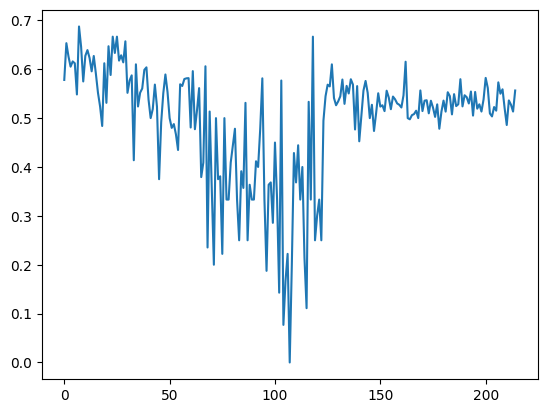

In [144]:
# 20 ~ 51 -100~100
# 88 ~ 137 -100~100
# 157 ~ 235 #非常好(2) #好(1) #無關(0) #不好(-1) #非常不好(-2)

# 20230101 ~ 20231231 一年前5擋股票報酬率 1.405046
# 20230101 ~ 20231231 一年後5擋股票報酬率 1.5045
# 20220101 ~ 20231231 兩年的10擋股票報酬率 1.186132
# 20230101 ~ 20231231 一年的10擋股票報酬率 1.170022

import matplotlib.pyplot as plt
import ast
list_2 = []

for i in range(20, 235):
    acc_list = []
    bnhs = []
    eval_list = []

    with open("eval_gemini/output"+str(i), "r", encoding='utf-8') as f:
        data = f.read()
        eval_list = ast.literal_eval(data.split("原始數據")[1])

    g = 0
    d = 0

    for idx, list in enumerate(eval_list):
        # if idx == 3:
        #     continue
        t, f = eval(list)
        # print(f'報酬率:{rtn}，總額投入報酬率:{bnh} ',end="==>")  
        # print("勝利" if rtn > bnh else "失敗")
        # print("執行完1個LIST",t, f)
        g += t
        d += f

    print("_"*50)
    print(i-19,g, d, g/(g+d))
    list_2.append(g/(g+d))
    # print(f'{i} 平均報酬率:{sum(rtns) / len(rtns)}，平均總額投入報酬率:{sum(bnhs) / len(bnhs)}')
    # print(str(i) + " 策略勝利" if sum(rtns) / len(rtns) > 1.186132 else str(i) + " 策略失敗" + str(sum(rtns) / len(rtns)))
    # list_2.append(sum(rtns) / len(rtns))

plt.plot(list_2)
print(list_2)